In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
print("이미지 업로드")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
img_bgr = cv2.imread(img_path)

assert img_bgr is not None, "이미지 로드 실패"
print("로드 완료:", img_path)
print("image shape:", img_bgr.shape)

이미지 업로드


Saving ek.jpeg to ek (2).jpeg
로드 완료: ek (2).jpeg
image shape: (512, 518, 3)


In [ ]:
def show_bgr(img_bgr, title="image", figsize=(8, 8)):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


def draw_landmark_indices(
    image_bgr,
    landmarks,
    radius=2,
    font_scale=0.4,
    thickness=1,
    point_color=(0, 255, 0),
    text_color=(0, 0, 255)
):
    vis = image_bgr.copy()
    landmarks = np.asarray(landmarks, dtype=np.float32)

    assert landmarks.ndim == 2 and landmarks.shape[1] == 2, \
        f"landmarks shape must be (N,2), got {landmarks.shape}"

    for i, (x, y) in enumerate(landmarks):
        x_i = int(round(float(x)))
        y_i = int(round(float(y)))

        cv2.circle(vis, (x_i, y_i), radius, point_color, -1)
        cv2.putText(
            vis,
            str(i),
            (x_i + 3, y_i - 3),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            text_color,
            thickness,
            cv2.LINE_AA
        )
    return vis

In [ ]:
np.set_printoptions(precision=3, suppress=True)
print(landmarks68)

[[181.3  179.2 ]
 [207.2  174.08]
 [233.1  168.96]
 [259.   174.08]
 [284.9  179.2 ]
 [196.84 230.4 ]
 [259.   245.76]
 [321.16 230.4 ]]


In [ ]:
np.savetxt("landmarks68.txt", landmarks68, fmt="%.6f")
print("저장 완료: landmarks68.txt")
files.download("landmarks68.txt")

저장 완료: landmarks68.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

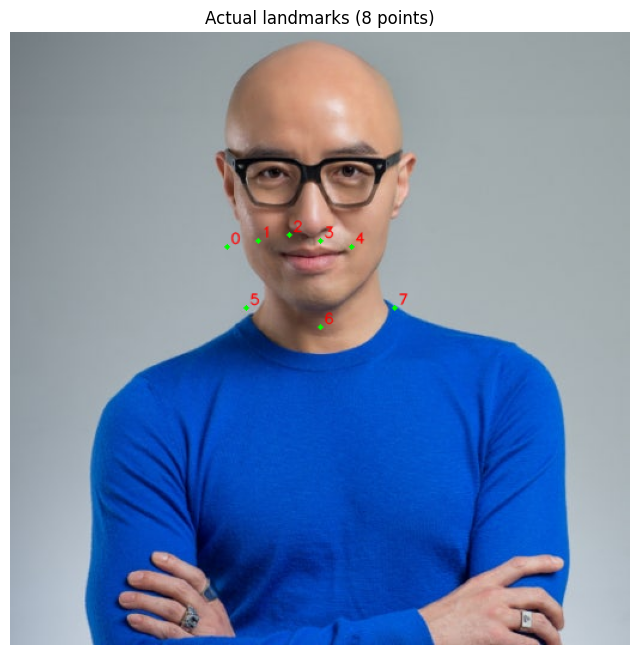

In [ ]:
vis = draw_landmark_indices(img_bgr, landmarks68)
show_bgr(vis, title=f"Actual landmarks ({len(landmarks68)} points)")

이미지 업로드


Saving ek.jpeg to ek (1).jpeg


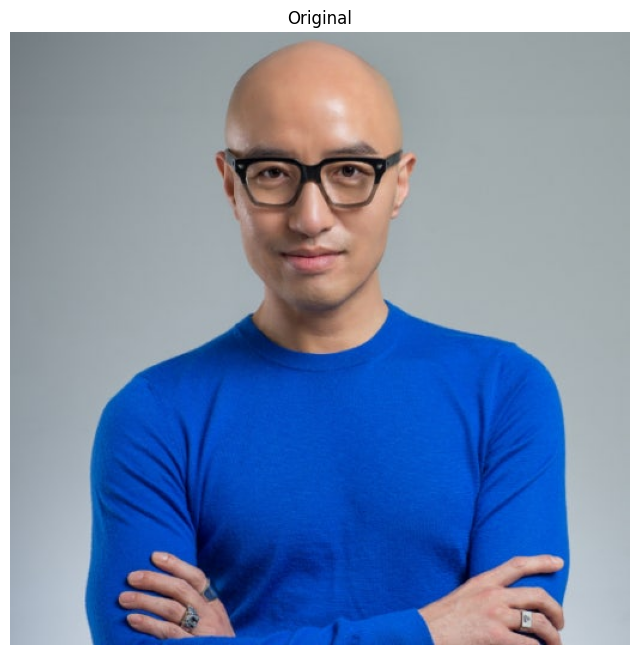

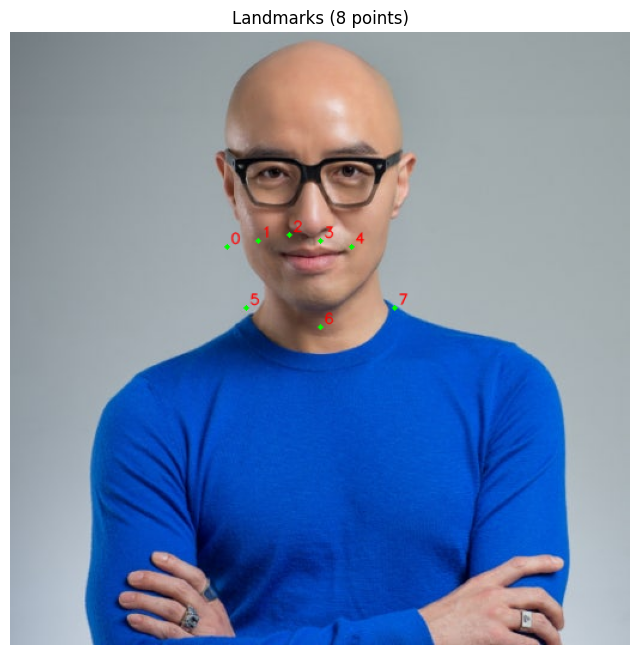

저장 완료: landmark_vis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def show_bgr(img_bgr, title="image", figsize=(8, 8)):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

def draw_landmark_indices(
    image_bgr,
    landmarks,
    radius=2,
    font_scale=0.4,
    thickness=1,
    point_color=(0, 255, 0),
    text_color=(0, 0, 255)
):
    vis = image_bgr.copy()
    landmarks = np.asarray(landmarks, dtype=np.float32)

    assert landmarks.ndim == 2 and landmarks.shape[1] == 2, "landmarks shape must be (N,2)"

    for i, (x, y) in enumerate(landmarks):
        x_i = int(round(float(x)))
        y_i = int(round(float(y)))
        cv2.circle(vis, (x_i, y_i), radius, point_color, -1)
        cv2.putText(
            vis, str(i), (x_i + 3, y_i - 3),
            cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, thickness, cv2.LINE_AA
        )
    return vis

def crop_landmarks_to_full_image(crop_landmarks, bbox, crop_size=128):
    crop_landmarks = np.asarray(crop_landmarks, dtype=np.float32)
    x, y, w, h = bbox

    full_landmarks = np.zeros_like(crop_landmarks, dtype=np.float32)
    full_landmarks[:, 0] = crop_landmarks[:, 0] * (w / crop_size) + x
    full_landmarks[:, 1] = crop_landmarks[:, 1] * (h / crop_size) + y
    return full_landmarks

print("이미지 업로드")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img_bgr = cv2.imread(img_path)
assert img_bgr is not None, "이미지 로드 실패"

show_bgr(img_bgr, title="Original")

# ===== 여기 네 랜드마크 넣으면 됨 =====
# 예시 8개 점
h, w = img_bgr.shape[:2]
landmarks68 = np.array([
    [w * 0.35, h * 0.35],
    [w * 0.40, h * 0.34],
    [w * 0.45, h * 0.33],
    [w * 0.50, h * 0.34],
    [w * 0.55, h * 0.35],
    [w * 0.38, h * 0.45],
    [w * 0.50, h * 0.48],
    [w * 0.62, h * 0.45],
], dtype=np.float32)

vis = draw_landmark_indices(img_bgr, landmarks68)
show_bgr(vis, title=f"Landmarks ({len(landmarks68)} points)")

cv2.imwrite("landmark_vis.png", vis)
print("저장 완료: landmark_vis.png")
files.download("landmark_vis.png")